In [9]:
import pandas as pd

# Cargar dataset
df = pd.read_csv("/content/drive/MyDrive/PYTHON/Fundamentos de ML/comentarios_deportivos.csv")

# Asegurar que los comentarios sean texto
df['comentario'] = df['comentario'].astype(str)

# Vista rápida
df.head()                   # 4. Para datos de ejemplo.

,id,comentario,sentimiento
0,180,"Partido equilibrado, resultado justo.",Neutral
1,177,"Encuentro equilibrado, reparto justo de puntos.",Neutral
2,189,Resultado esperado dadas las circunstancias.,Neutral
3,132,Nuestro ataque no generó peligro suficiente.,Negativo
4,148,"Sin sobresaltos, rendimiento promedio.",Neutral


In [10]:
import re

# Función simple y efectiva para limpiar texto
def limpiar_texto_simple(texto):
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúñü\s]", "", texto)  # Solo letras y espacios
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# Aplicar limpieza
df['comentario_limpio'] = df['comentario'].apply(limpiar_texto_simple)

# Revisar ejemplos
df[['comentario', 'comentario_limpio']].sample(10)

,comentario,comentario_limpio
79,"Perdimos merecidamente, mal rendimiento general.",perdimos merecidamente mal rendimiento general
62,"Partido equilibrado, resultado justo.",partido equilibrado resultado justo
43,La defensa estuvo impecable hoy.,la defensa estuvo impecable hoy
28,Empate que refleja claramente el rendimiento.,empate que refleja claramente el rendimiento
26,"Perdimos merecidamente, mal rendimiento general.",perdimos merecidamente mal rendimiento general
116,Partido sin mucha emoción.,partido sin mucha emoción
96,Actuación brillante del mediocampo.,actuación brillante del mediocampo
52,"Actuación normal, nada destacable.",actuación normal nada destacable
174,Errores constantes en pases y posesión.,errores constantes en pases y posesión
167,"Mal partido, fallamos demasiadas oportunidades.",mal partido fallamos demasiadas oportunidades


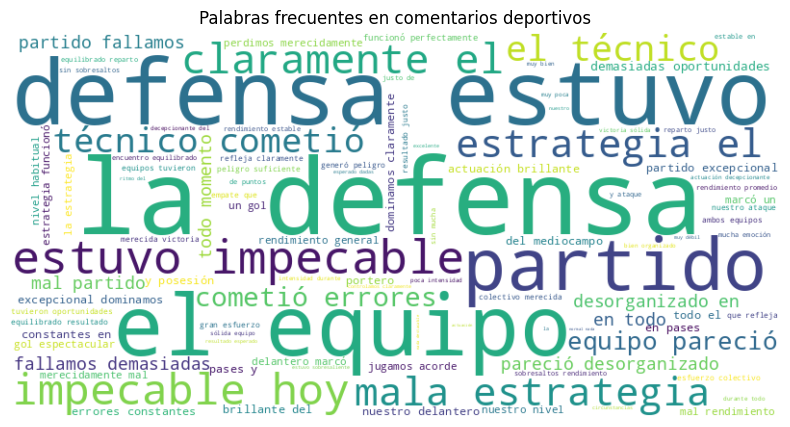

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filtrar comentarios útiles
df_filtrado = df[df['comentario_limpio'].str.strip().astype(bool)]

# Unir todos los comentarios limpios
texto_total = ' '.join(df_filtrado['comentario_limpio'])

# Generar nube
if texto_total:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto_total)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title("Palabras frecuentes en comentarios deportivos")
    plt.show()
else:
    print("⚠️ No hay palabras útiles después del preprocesamiento.")

/tmp/ipykernel_7295/2183315899.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentimiento', data=df, palette='viridis')


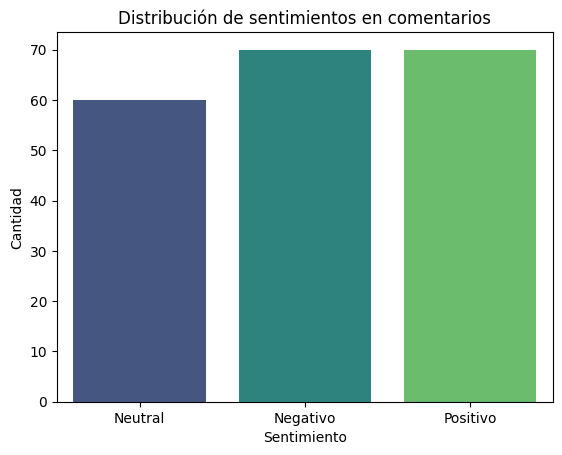

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Verificar columna
if 'sentimiento' in df.columns:
    sns.countplot(x='sentimiento', data=df, palette='viridis')
    plt.title('Distribución de sentimientos en comentarios')
    plt.xlabel('Sentimiento')
    plt.ylabel('Cantidad')
    plt.show()
else:
    print("⚠️ No se encontró la columna 'sentimiento'.")

In [13]:
import ipywidgets as widgets
from IPython.display import display

sentimiento_widget = widgets.Dropdown(options=df['sentimiento'].unique(), description='Sentimiento:')

def mostrar_comentarios(sentimiento):
    seleccionados = df[df['sentimiento'] == sentimiento]
    display(seleccionados[['comentario', 'comentario_limpio']].sample(5))

widgets.interactive(mostrar_comentarios, sentimiento=sentimiento_widget)

interactive(children=(Dropdown(description='Sentimiento:', options=('Neutral', 'Negativo', 'Positivo'), value=…